In [ ]:
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jrandom
from jaxtyping import Array, PRNGKeyArray

import equinox as eqx
from equinox._module import field
from equinox._misc import default_floating_dtype
import optax

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import math
from typing import Callable, Optional

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# Read the training data

In [ ]:
# load entire dataset into pandas
df = pd.read_csv('./data/preprocessed.csv', index_col=0,)
df.head()

# Data preprocessing

## Data normalization

In [ ]:
scaler, df_norm = {}, df.copy()

for varn in df.columns:
    # scaler_v = StandardScaler()
    scaler_v = MinMaxScaler()
    df_norm[varn] = scaler_v.fit_transform(df[[varn]].values)
    scaler[varn] = scaler_v

In [ ]:
varns = df_norm.keys().to_list()
fig, axes = plt.subplots(4, 1, figsize=(10,15))
for i,ax in enumerate(axes):
    varn = varns[i]
    df_norm[varn].plot(ax=ax)
    ax.set(title=varn)

## Split the data into training and test sets

In [ ]:
train_start = '1979-10-01' # starts 1 year later due to padding in figure
train_end = '2010-09-30'

test_start = '2010-10-01' # starts 1 year later due to padding in figure
test_end = '2018-09-30'


In [ ]:
# divide dataset in training and test set
df_norm_train = df_norm.loc[train_start:train_end].copy()
df_norm_test = df_norm.loc[test_start:test_end].copy()

# print fraction the test set is of all the used data
print('Test set fraction: ', len(df_norm_test) / (len(df_norm_train) + len(df_norm_test)))

# Rainfall-Runoff modeling

## Configuration

In [ ]:
# Model output variable
target   = 'Q'

# Model input feature
features = list(df_norm.columns.difference([target]))
# features = ['P']

# DL model configuration and training settings
sequence_length = 365
batch_size = 512
learning_rate = 0.001
hidden_size = 20
epochs = 50

# Random keys
data_key, model_key = jrandom.split(jrandom.PRNGKey(1024), 2)


## Create a pytorch custom dataset

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, dataframe, target, features, sequence_length=5):

        # save which are the features and target data and sequence length
        self.features = features
        self.target = target
        self.sequence_length = sequence_length

        # load data from dataframe into tensor
        y = torch.tensor(dataframe[self.target].values).float()
        X = torch.tensor(dataframe[self.features].values).float()

        # remove padding from data and save data in class
        self.y = y[sequence_length:]
        self.X = X[sequence_length:,:]

        # make extra dataseries for padding
        self.yPadding = y[:sequence_length*2]
        self.XPadding = X[:sequence_length*2,:]
        # self.sequence_length = sequence_length


    def __len__(self):

        # return length shape
        return self.X.shape[0]


    def __getitem__(self, i): 
        # select data from the dataset without padding and return data
        if i > self.sequence_length:
            Xr = self.X[i-self.sequence_length:i,:]
            yr = self.y[i-1]

            return Xr, yr
          
        # select from the padding dataset and return data
        else:
            Xr = self.XPadding[i:i+self.sequence_length,:]
            yr = self.yPadding[i+self.sequence_length - 1]

            return Xr, yr


In [ ]:
# make train and test dataset
train_dataset = TimeSeriesDataset(df_norm_train,
                                  target=[target],
                                  features=features,
                                  sequence_length=sequence_length)
test_dataset = TimeSeriesDataset(df_norm_test,
                                target=[target],
                                features=features,
                                sequence_length=sequence_length)

# load dataset in DataLoader
train_loader = DataLoader(train_dataset, 
                          batch_size=batch_size, 
                          shuffle=True)
test_loader = DataLoader(test_dataset, 
                         batch_size=batch_size, 
                         shuffle=False)
train_eval_loader = DataLoader(train_dataset, 
                               batch_size=batch_size,  
                               shuffle=False)

## Define a LSTM model using JAX

In [ ]:
class LSTMCell(eqx.Module, strict=True):
    weight_ih: Array
    weight_hh: Array
    biasi: Optional[Array]
    biash: Optional[Array]
    input_size: int = field(static=True)
    hidden_size: int = field(static=True)
    use_bias: bool = field(static=True)

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        use_bias: bool = True,
        dtype=None,
        *,
        key: PRNGKeyArray,
    ):
        """**Arguments:**

        - `input_size`: The dimensionality of the input vector at each time step.
        - `hidden_size`: The dimensionality of the hidden state passed along between
            time steps.
        - `use_bias`: Whether to add on a bias after each update.
        - `dtype`: The dtype to use for all weights and biases in this LSTM cell.
            Defaults to either `jax.numpy.float32` or `jax.numpy.float64` depending on
            whether JAX is in 64-bit mode.
        - `key`: A `jax.random.PRNGKey` used to provide randomness for parameter
            initialisation. (Keyword only argument.)
        """
        dtype = default_floating_dtype() if dtype is None else dtype
        ihkey, hhkey, bkey = jrandom.split(key, 3)
        lim = math.sqrt(1 / hidden_size)

        ihshape = (4 * hidden_size, input_size)
        self.weight_ih = jrandom.uniform(ihkey, ihshape, dtype, minval=-lim, maxval=lim)
        hhshape = (4 * hidden_size, hidden_size)
        self.weight_hh = jrandom.uniform(hhkey, hhshape, dtype, minval=-lim, maxval=lim)
        bshape = (4 * hidden_size,)
        self.biasi = jrandom.uniform(bkey, bshape, dtype, minval=-lim, maxval=lim) if use_bias else None
        self.biash = jrandom.uniform(bkey, bshape, dtype, minval=-lim, maxval=lim) if use_bias else None

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.use_bias = use_bias

    def __call__(self, input, hidden, *, key=None):
        """**Arguments:**

        - `input`: The input, which should be a JAX array of shape `(input_size,)`.
        - `hidden`: The hidden state, which should be a 2-tuple of JAX arrays, each of
            shape `(hidden_size,)`.
        - `key`: Ignored; provided for compatibility with the rest of the Equinox API.
            (Keyword only argument.)

        **Returns:**

        The updated hidden state, which is a 2-tuple of JAX arrays, each of shape
        `(hidden_size,)`.
        """
        h, c = hidden
        lin = self.weight_ih @ input + self.weight_hh @ h
        if self.use_bias:
            lin = lin + self.biasi + self.biash
        i, f, g, o = jnp.split(lin, 4)
        i = jnn.sigmoid(i)
        f = jnn.sigmoid(f)
        g = jnn.tanh(g)
        o = jnn.sigmoid(o)
        c = f * c + i * g
        h = o * jnn.tanh(c)
        return (h, c)

In [175]:
class LSTM(eqx.Module):
    hidden_size: int
    cell: eqx.Module
    linear: eqx.nn.Linear

    def __init__(self, in_size, out_size, hidden_size, *, key):
        ckey, lkey = jrandom.split(key)
        self.hidden_size = hidden_size
        self.cell = eqx.nn.LSTMCell(in_size, hidden_size, use_bias=False, key=ckey)
        self.linear = eqx.nn.Linear(hidden_size, out_size, use_bias=True, key=lkey)

    def __call__(self, input):
        init_state = (jnp.zeros(self.cell.hidden_size),
                      jnp.zeros(self.cell.hidden_size))

        def f(carry, inp):
            h,c = self.cell(inp, carry)
            return (h,c), (h,c)
        states_t, states_all = jax.lax.scan(f, init_state, input)
        
        # h_all, c_all = states_all
        # vmap = jax.vmap(lambda h: self.linear(h), in_axes=0)
        # h_trans_all = vmap(h_all)
        # return h_trans_all[-1]
        
        ht, ct = states_t
        return self.linear(ht)
    
    def output_all(self, input):
        init_state = (jnp.zeros(self.cell.hidden_size),
                      jnp.zeros(self.cell.hidden_size))

        def f(carry, inp):
            h,c = self.cell(inp, carry)
            return (h,c), (h,c)
        states_t, states_all = jax.lax.scan(f, init_state, input)
        
        h_all, c_all = states_all
        vmap = jax.vmap(lambda h: self.linear(h), in_axes=0)
        h_trans_all = vmap(h_all)
        c_trans_all = vmap(c_all)
        # return h_trans_all, c_trans_all
        ht, ct = states_t
        outh, outc = self.linear(ht), self.linear(ct)
        return outh, outc, h_trans_all, c_trans_all


In [176]:
# check if the features and targets are made accordingly with the right shapes
# and sizes(trust us, they are)
X, y = next(iter(train_loader))
print('Features shape:', X.shape)
print('Target shape:', y.shape)

# model = eqx.nn.MLP(in_size=len(features)*batch_size, out_size=1, width_size=hidden_size, depth=hidden_size, key=model_key)
model = LSTM(in_size=len(features), out_size=1, hidden_size=hidden_size, key=model_key)
model

Features shape: torch.Size([512, 365, 3])
Target shape: torch.Size([512, 1])


LSTM(
  hidden_size=20,
  cell=LSTMCell(
    weight_ih=f32[80,3],
    weight_hh=f32[80,20],
    bias=None,
    input_size=3,
    hidden_size=20,
    use_bias=False
  ),
  linear=Linear(
    weight=f32[1,20],
    bias=f32[1],
    in_features=20,
    out_features=1,
    use_bias=True
  )
)

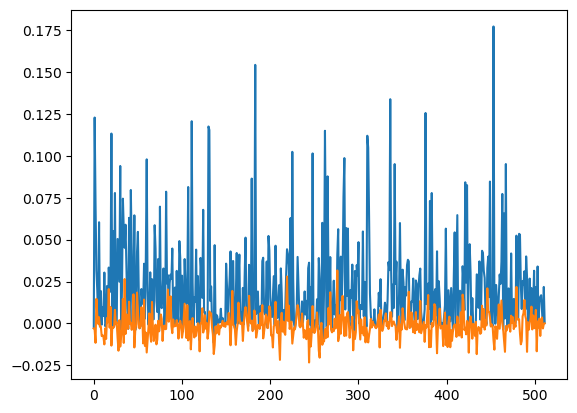

In [198]:
x = jnp.array(X)
y1 = jax.vmap(model)(x)

x = x.at[:,:,0].set(0.0)
y2 = jax.vmap(model)(x)

plt.plot(y1)
plt.plot(y2)

## Train the DL model

In [177]:
# Define a loss function
def loss_mse(model, x, y):
    # jax.debug.print("x = {x}", x=x.shape)
    pred_y = jax.vmap(model)(x)
    return jnp.mean((y - pred_y) ** 2)


In [178]:
@eqx.filter_jit
def make_step(model, opt_state, x, y,loss_func, optim):
    loss_value, grads = eqx.filter_value_and_grad(loss_func)(model, x, y)
    updates, opt_state = optim.update(grads, opt_state, model)
    # updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

def train_each_step(model, trainloader, loss_func, optim, opt_state):
    train_loss, k = 0, 0
    num_batches = len(trainloader)
    for i, (x, y) in enumerate(trainloader):
        x, y = jnp.array(x), jnp.array(y)
        model, opt_state, train_loss_each = make_step(model, opt_state, x, y, loss_func, optim)
        k += 1
        train_loss += train_loss_each
    train_loss /= num_batches
    print(f"Training loss: {train_loss}")
    return model, opt_state, train_loss

def evaluate(model, testloader, loss_func):
    test_loss, k = 0, 0
    num_batches = len(testloader)
    loss_func = eqx.filter_jit(loss_func)
    for i, (x, y) in enumerate(testloader):
        x, y = jnp.array(x), jnp.array(y)
        test_loss_each = loss_func(model, x, y)
        k += 1
        test_loss += test_loss_each
    
    # print(f'Test loss: {test_loss}')
    test_loss /= num_batches
    print(f'Test loss: {test_loss}')
    return test_loss

def train(model, nsteps, loss_func, optim, trainloader, testloader):
    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    loss_train_set, loss_test_set = [], []
    for step in range(nsteps):
        print('\n')
        print(f'Epoch {step}\n-----')
        # Update the model on the training data
        model, opt_state, loss_value_train = train_each_step(
            model, trainloader, loss_func, optim, opt_state)

        # Evaluate the model on the test data
        if testloader is not None:
            loss_value_test = evaluate(model, testloader, loss_func)
            loss_train_set.append(loss_value_train)
            loss_test_set.append(loss_value_test)
        else:
            loss_train_set.append(loss_value_train)
    
    loss_train_set = jnp.array(loss_train_set)
    loss_test_set = jnp.array(loss_test_set)
    
    return model, loss_train_set, loss_test_set

# def predict(data_loader, model):
#     # initiaze output data
#     y_pred_set = []

#     # iterate through data from data loader and make prediction
#     for i, (x,y) in enumerate(data_loader):
#         x, y = jnp.array(x), jnp.array(y)
#         y_pred = jax.vmap(model)(x)
#         y_pred_set.append(y_pred)
#         # y_pred_set = jnp.concatenate((y_pred_set, y_pred), 0)
    
#     return jnp.concatenate(y_pred_set, 0)

def predict(data_loader, model):
    # initiaze output data
    y_pred_set = []
    yc_pred_set = []
    ht_pred_set = []
    ct_pred_set = []

    # iterate through data from data loader and make prediction
    for i, (x,y) in enumerate(data_loader):
        x, y = jnp.array(x), jnp.array(y)
        y_pred, yc_pred, ht_pred, ct_pred = jax.vmap(model.output_all)(x)
        # y_pred_set.append(ht_pred[:,-1])
        y_pred_set.append(y_pred)
        yc_pred_set.append(yc_pred)
        ht_pred_set.append(ht_pred)
        ct_pred_set.append(ct_pred)
        # y_pred_set = jnp.concatenate((y_pred_set, y_pred), 0)
    
    return jnp.concatenate(y_pred_set, 0), \
           jnp.concatenate(yc_pred_set, 0), \
           jnp.concatenate(ht_pred_set, 0), \
           jnp.concatenate(ct_pred_set, 0)


In [199]:
evaluate(model, test_loader, loss_mse)

Test loss: 0.0002429103769827634


Array(0.00024291, dtype=float32)

In [180]:
# test_model(model, test_loader, loss_mse)
optim = optax.adamw(learning_rate)
model, loss_train, loss_test = train(model, epochs, loss_mse, optim, train_loader, test_loader)




Epoch 0
-----
Training loss: 0.0016093808226287365
Test loss: 0.0012771458132192492


Epoch 1
-----
Training loss: 0.001083043753169477
Test loss: 0.0008514926885254681


Epoch 2
-----
Training loss: 0.0008319353219121695
Test loss: 0.0007054980378597975


Epoch 3
-----
Training loss: 0.000728523125872016
Test loss: 0.0006118793971836567


Epoch 4
-----
Training loss: 0.0006461239536292851
Test loss: 0.0005314254085533321


Epoch 5
-----
Training loss: 0.0005498748505488038
Test loss: 0.00045289425179362297


Epoch 6
-----
Training loss: 0.000492411432787776
Test loss: 0.0004345751367509365


Epoch 7
-----
Training loss: 0.0004755283589474857
Test loss: 0.00038815251900814474


Epoch 8
-----
Training loss: 0.0004565737908706069
Test loss: 0.0003736199578270316


Epoch 9
-----
Training loss: 0.00043330545304343104
Test loss: 0.0003704299160744995


Epoch 10
-----
Training loss: 0.000422873068600893
Test loss: 0.00034444223274476826


Epoch 11
-----
Training loss: 0.0004052694712299853

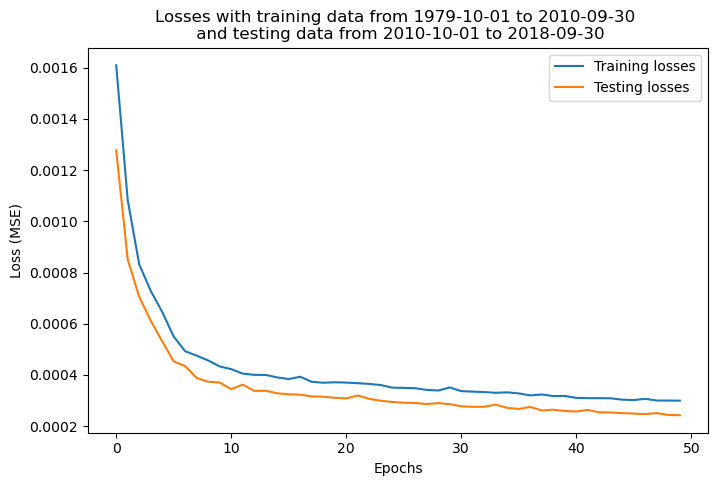

In [181]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(loss_train, label='Training losses')
ax.plot(loss_test, label='Testing losses')
ax.set(title=f'Losses with training data from {train_start} to {train_end} \n and testing data from {test_start} to {test_end}',
       ylabel='Loss (MSE)', xlabel='Epochs')
ax.legend(loc='upper right');


## Prediction

In [185]:
# predict data with model
y_pred_train, yc_pred_train, ht_trans_train, ct_trans_train = predict(train_eval_loader, model)
y_pred_test, yc_pred_test, ht_trans_test, ct_trans_test = predict(test_loader, model)

# make placeholder for model output data
y_pred_col = 'LSTM model discharge prediction'

# load data in dataframe
df_train_out = pd.DataFrame(index=df_norm_train.index[sequence_length:],
                            data={target:df_norm_train[target][sequence_length:],
                                  'c':yc_pred_train.flatten(),
                                  y_pred_col:y_pred_train.flatten()})
df_train_h = pd.DataFrame(index=df_norm_train.index[sequence_length:],
                          data=ht_trans_train[:,::-1,-1])
df_train_c = pd.DataFrame(index=df_norm_train.index[sequence_length:],
                          data=ct_trans_train[:,::-1,-1])

df_test_out = pd.DataFrame(index=df_norm_test.index[sequence_length:],
                        data={target:df_norm_test[target][sequence_length:],
                              'c':yc_pred_test.flatten(),
                              y_pred_col:y_pred_test.flatten()})
df_test_h = pd.DataFrame(index=df_norm_test.index[sequence_length:],
                          data=ht_trans_test[:,::-1,-1])
df_test_c = pd.DataFrame(index=df_norm_test.index[sequence_length:],
                          data=ct_trans_test[:,::-1,-1])

# de-normalize data
for col in df_train_out.columns:
    df_train_out[col] = scaler[target].inverse_transform(df_train_out[[col]].values)

for col in df_test_out.columns:
    df_test_out[col] = scaler[target].inverse_transform(df_test_out[[col]].values)

# calculate RMSE for both datasets
RMSE_test = ((df_test_out[target] - df_test_out[y_pred_col]) ** 2).mean() ** .5
RMSE_train = ((df_train_out[target] - df_train_out[y_pred_col]) ** 2).mean() ** .5
CC_test  = jnp.corrcoef(df_test_out[target].values, df_test_out[y_pred_col].values)[0,1]
CC_train = jnp.corrcoef(df_train_out[target].values, df_train_out[y_pred_col].values)[0,1]


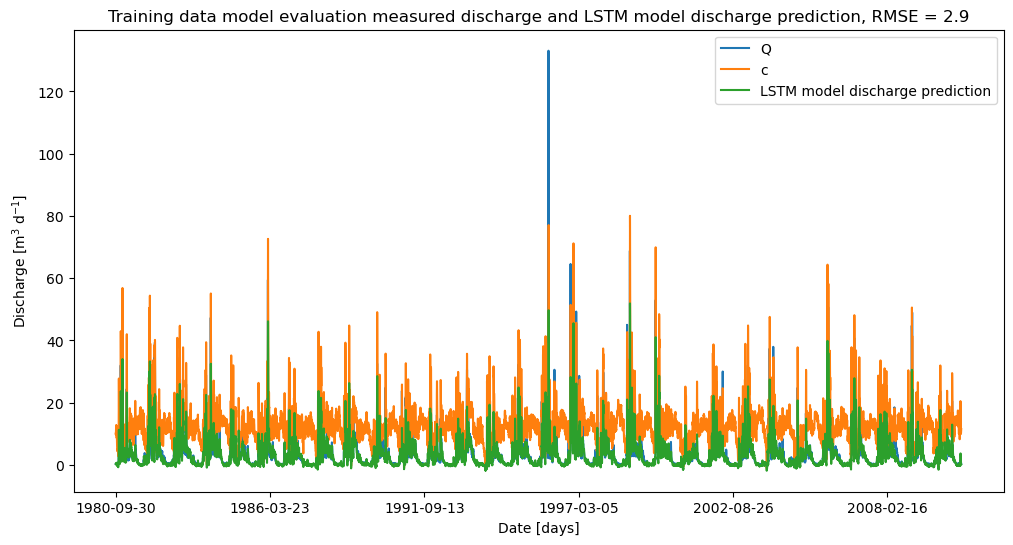

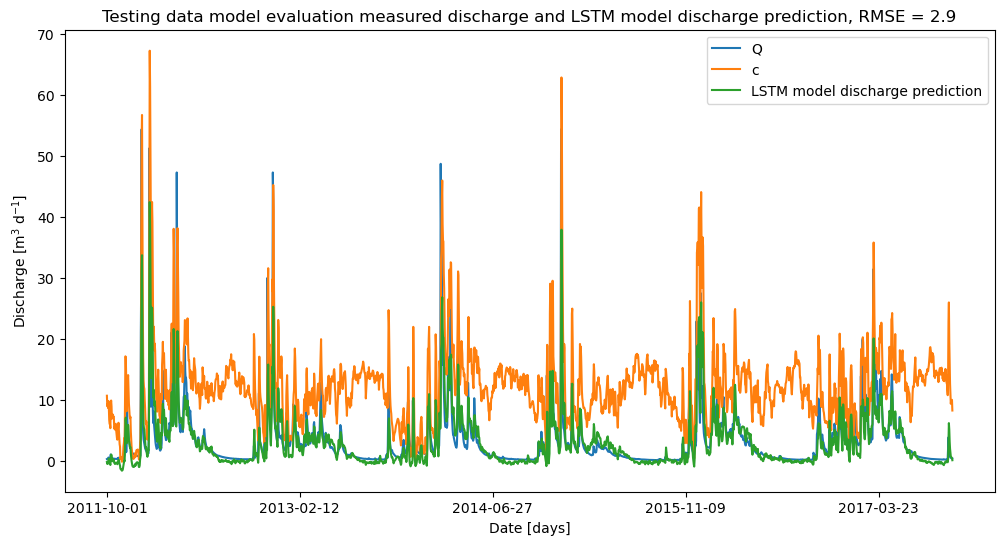

In [188]:
# plot
fig,ax = plt.subplots(figsize=(12,6))
df_train_out.plot(ax=ax)
ax.set_ylabel('Discharge [m$^3$ d$^{-1}$]');
ax.set_xlabel('Date [days]');
ax.set_title(f'Training data model evaluation measured discharge and LSTM model discharge prediction, RMSE = {RMSE_train:.2}');
fig.show()

# plot
fig,ax = plt.subplots(figsize=(12,6))
df_test_out.plot(ax=ax)
ax.set_ylabel('Discharge [m$^3$ d$^{-1}$]');
ax.set_xlabel('Date [days]');
ax.set_title(f'Testing data model evaluation measured discharge and LSTM model discharge prediction, RMSE = {RMSE_test:.2}');
fig.show()


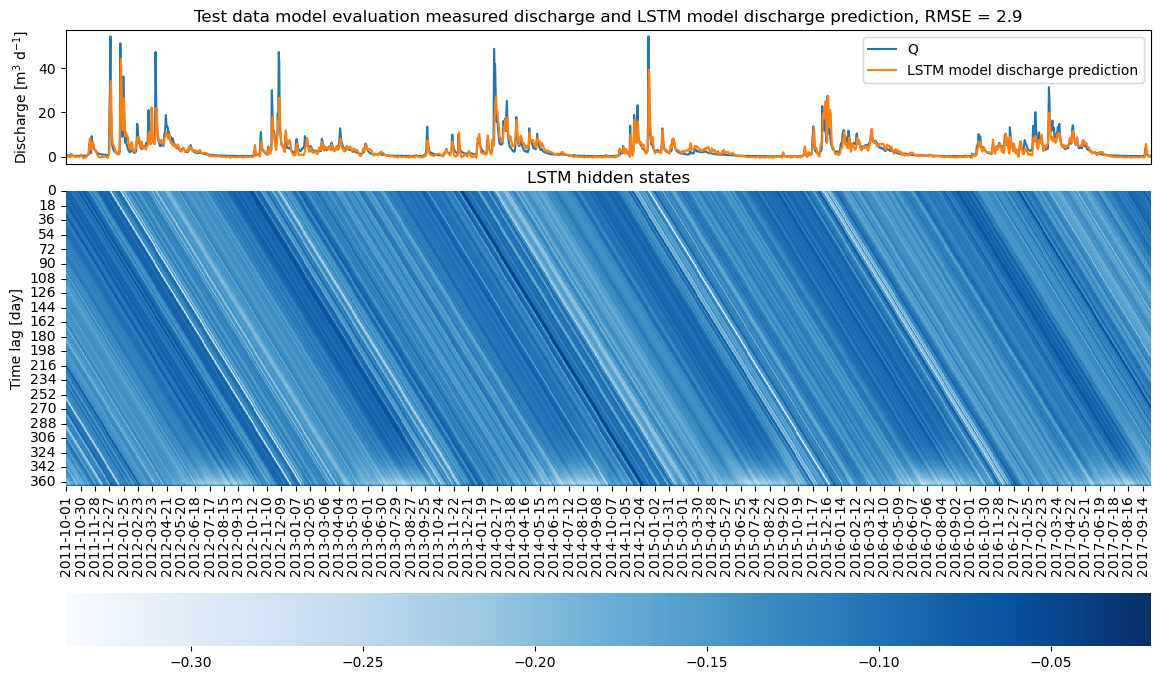

In [142]:
# Test period
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(ncols=8, nrows=8, figure=fig,hspace=0.5)
ax1 = fig.add_subplot(gs[2:-2,:])
ax2, ax3 = fig.add_subplot(gs[-1,:]), fig.add_subplot(gs[:2,:])

ax1=sns.heatmap(
    df_test_c.T, cmap='Blues', ax=ax1, cbar_ax=ax2, 
    # ht_trans_test[:,::-1,3].T, cmap='Blues', ax=ax1, cbar_ax=ax2, 
    cbar_kws={'orientation':'horizontal', 'fraction':'0.07', 'anchor':(1,-0.5)}
)
ax1.set(title='LSTM hidden states', ylabel='Time lag [day]')
df_test_out.plot(ax=ax3)
ax3.set(ylabel='Discharge [m$^3$ d$^{-1}$]', xlabel='', xlim=ax1.get_xlim(), xticks=[],
        title=f'Test data model evaluation measured discharge and LSTM model discharge prediction, RMSE = {RMSE_train:.2}');

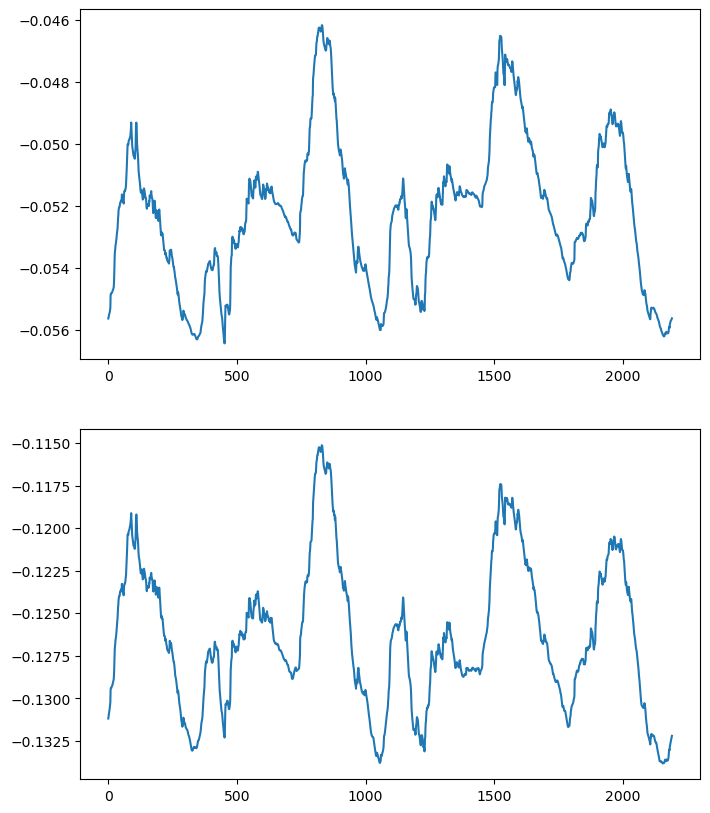

In [147]:
fig, axes = plt.subplots(2, 1, figsize=(8,10))
# for i in range(20):
#     axes[0].plot(ht_trans_test[:,::-1,i].mean(axis=0))
#     axes[1].plot(ct_trans_test[:,::-1,i].mean(axis=0))
axes[0].plot(df_test_h.values.mean(axis=1))
axes[1].plot(df_test_c.values.mean(axis=1));
